In [5]:
# option_dict = {
#     'snapshot' : 'public_for_260105',
#     'year_range' : '2020to2025'
# }

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.datetime_handler import calc_rel_period
from matplotlib import pyplot as plt
from lib.visualization.plot_generator import PlotGen

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams.update(font_setting.fig_setting)





In [7]:
def compute_N_by_week(lang, df, period_col='rel_week', weight_col='tot_pct'):
    N = df.groupby(period_col)[weight_col].sum().reset_index()
    N.columns = ["rel_week", "n_docs"]
    N["language"] = lang
    return N


In [16]:
def draw_graph(df, x, y, lang):


    df = pd.DataFrame({'rel_week': df[x].tolist()  , 'count': df[y].tolist()})

    TIME_COL   = 'rel_week'
    VALUE_COL  = 'count'
    XLABEL     = 'Weeks relative to ChatGPT release'
    YLABEL     = 'Number of questions'
    PANEL_LBL  = None        # 'A' 같은 라벨 표시하려면 문자열, 안 쓰면 None
    LANG_NAME  = None        # 'Python' 같은 그룹명 표시하려면 문자열, 안 쓰면 None
    # EVENT_LBL  = 'ChatGPT release'
    SMOOTH_WIN = 8

    OUT_PNG = 'figure_bar.png'
    OUT_PDF = 'figure_bar.pdf'


    # ============================================================
    # 3. Smoothing
    # ============================================================
    df = df.sort_values(TIME_COL).reset_index(drop=True)
    x = df[TIME_COL].values
    y = df[VALUE_COL].values.astype(float)
    y_smooth = pd.Series(y).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().values

    # ============================================================
    # 4. Plot
    # ============================================================
    fig, ax = plt.subplots(figsize=(3.5, 2.4), dpi=300)

    # Pre 구간 배경
    ax.axvspan(x.min(), 0, color='#F2F2F2', alpha=0.6, lw=0)

    # 막대 — 옅게
    ax.bar(x, y, width=1.0, color='#A9CCE3', edgecolor='none',
        alpha=0.55, zorder=2, label='Weekly')

    # Smoothed line — 위에
    ax.plot(x, y_smooth, color='#1f4e79', lw=1.3, zorder=3,
            label=f'{SMOOTH_WIN}-wk rolling mean')

    # 이벤트 표시
    ymax = np.nanmax(y) * 1.05
    ax.axvline(0, color='#C0392B', lw=0.8, ls='--', zorder=1)
    # ax.annotate(EVENT_LBL, xy=(0, ymax*0.85), xytext=(10, ymax*0.85),
    #             fontsize=7.5, color='#C0392B', va='center',
    #             arrowprops=dict(arrowstyle='-', color='#C0392B', lw=0.5))

    # Pre/Post 라벨
    ax.text(x.min()/2, ymax*1.02, 'Pre',  fontsize=8, color='#666', ha='center')
    ax.text(x.max()/2, ymax*1.02, 'Post', fontsize=8, color='#666', ha='center')


    # Spine 정리
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['left'].set_position(('outward', 3))
    ax.spines['bottom'].set_position(('outward', 3))

    ax.set_xlabel(XLABEL)
    ax.set_ylabel(YLABEL)

    # y축 ×10³ 표기 (값 범위가 크면)
    if ymax >= 1000:
        yticks = ax.get_yticks()
        ax.set_yticks(yticks)
        ax.set_yticklabels([f'{t/1000:g}' for t in yticks])
        ax.set_ylabel(YLABEL + r' ($\times 10^{3}$)')

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, ymax * 1.1)

    # 패널 라벨 (None이면 건너뜀)
    if PANEL_LBL:
        ax.text(-0.22, 1.12, PANEL_LBL, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top', ha='left')

    # # 언어/그룹명 (None이면 건너뜀)
    # if LANG_NAME:
    #     ax.text(0.98, 0.95, LANG_NAME, transform=ax.transAxes,
    #             fontsize=9, fontweight='bold', color='#1f4e79',
    #             ha='right', va='top')

    ax.legend(loc='best', bbox_to_anchor=(0.98, 0.78),
          handlelength=1.6, borderpad=0.4)

    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(OUT_PDF,           bbox_inches='tight', facecolor='white')
    plt.show()

[Start....] drawing figures for python language


TTLibError: not enough 'glyf' table data

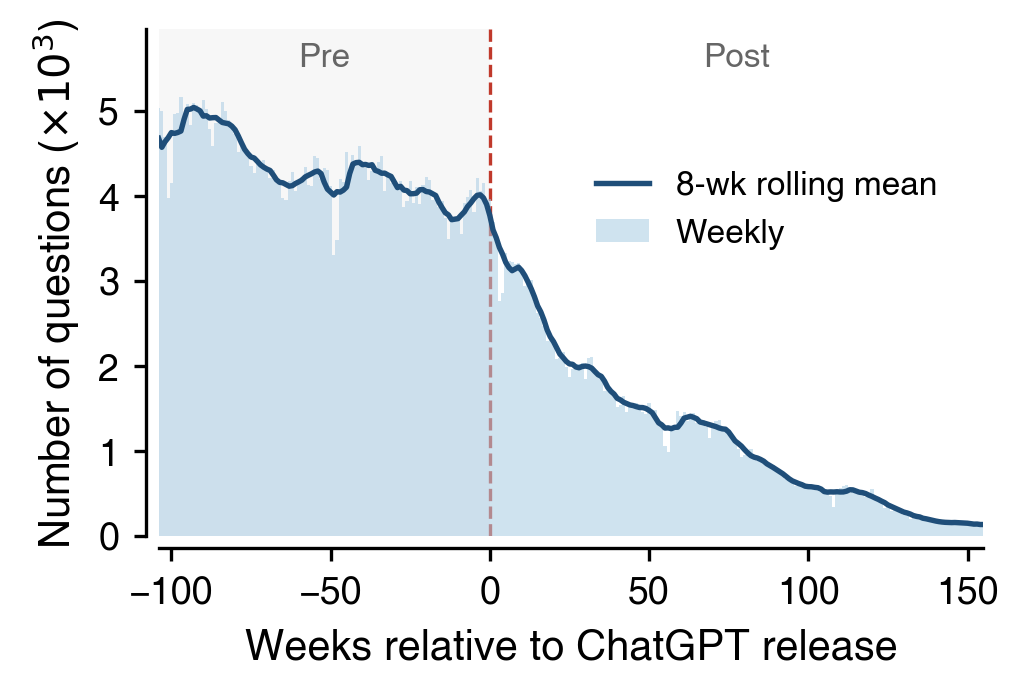

In [ ]:
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] drawing figures for {lang} language')
    plotgen = PlotGen(idx = 100+idx, model_in_run='tag')
    tmp = load_df(plotgen.data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'cdate', period = 7).reset_index()
    tmp = compute_N_by_week(lang, tmp, weight_col='pct')
    draw_graph(tmp, 'rel_week', 'n_docs', lang)
    
